Loaded ADM1 for United States of America (USA)
Loaded ADM1 for Chile (CHL)
Loaded ADM1 for Russia (RUS)
Loaded ADM1 for France (FRA)
Loaded ADM1 for Vietnam (VNM)
Loaded ADM1 for Sweden (SWE)
Loaded ADM1 for Austria (AUT)
Loaded ADM1 for Germany (DEU)
Loaded ADM1 for Greece (GRC)
Loaded ADM1 for Croatia (HRV)
Loaded ADM1 for Switzerland (CHE)
Loaded ADM1 for Luxembourg (LUX)
Loaded ADM1 for Belgium (BEL)
Loaded ADM1 for Netherlands (NLD)
Loaded ADM1 for Portugal (PRT)
Loaded ADM1 for Spain (ESP)
Loaded ADM1 for Ireland (IRL)
Loaded ADM1 for People's Republic of China (CHN)
Loaded ADM1 for Italy (ITA)
Loaded ADM1 for United Kingdom (GBR)
Loaded ADM1 for Czech Republic (CZE)


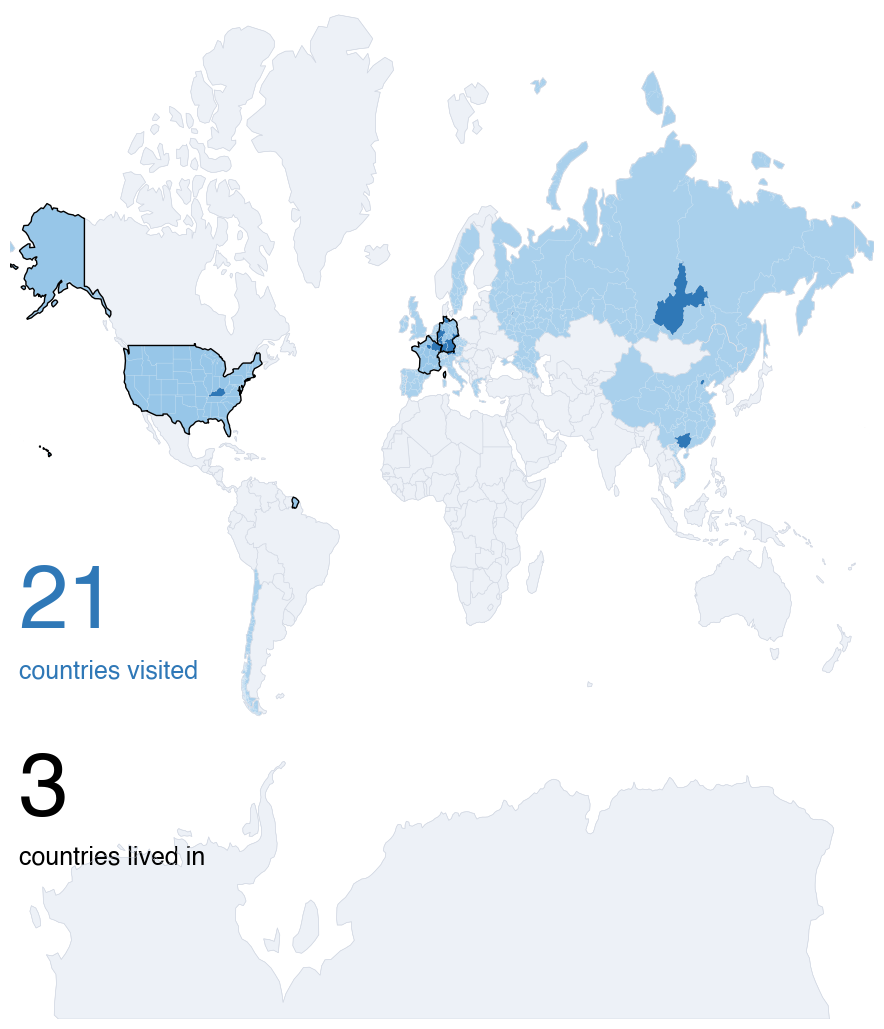


Projection mode: mercator

Countries with subdivisions shown:
- Austria
- Belgium
- Chile
- Croatia
- Czech Republic
- France
- Germany
- Greece
- Ireland
- Italy
- Luxembourg
- Netherlands
- People's Republic of China
- Portugal
- Russia
- Spain
- Sweden
- Switzerland
- United Kingdom
- United States of America
- Vietnam

Visited states found:
- United States of America : Hawaii
- United States of America : Kentucky
- Russia : Irkutsk Oblast
- Russia : Moscow
- France : Île-de-France
- France : Grand Est
- Austria : Salzburg
- Austria : Tirol
- Austria : Wien
- Germany : Baden-Württemberg
- Germany : Bayern
- Germany : Berlin
- Germany : Hamburg
- Germany : Nordrhein-Westfalen
- Germany : Rheinland-Pfalz
- Germany : Sachsen
- Germany : Schleswig-Holstein
- People's Republic of China : Guangxi Zhuang Autonomous Region
- People's Republic of China : Beijing Municipality


In [12]:
import requests
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

# -----------------------------
# 1) User input
# -----------------------------
# Countries where you have lived
lived_in = {
    "Germany",
    "France",
    "United States of America",
    # "China",
}

# Countries you have visited
visited = {
    "Germany",
    "France",
    "Austria",
    "Switzerland",
    "Luxembourg",
    "Netherlands",
    "Belgium",
    "United Kingdom",
    "Ireland",
    "United States of America",
    "Chile",
    "Vietnam",
    "Spain",
    "Portugal",
    "Czech Republic",
    "Sweden",
    "Italy",
    "Croatia",
    "Russia",
    "Greece",
    "China",
}

# Specific visited first-level administrative regions (ADM1)
# Keep user-friendly names here; country names will be normalized below.
visited_states = {
    ("Germany", "Bayern"),
    ("Germany", "Berlin"),
    ("Germany", "Hamburg"),
    ("Germany", "Nordrhein-Westfalen"),
    ("Germany", "Baden-Württemberg"),
    ("Germany", "Sachsen"),
    ("Germany", "Schleswig-Holstein"),
    ("Germany", "Rheinland-Pfalz"),

    ("Austria", "Wien"),
    ("Austria", "Tirol"),
    ("Austria", "Salzburg"),

    ("France", "Île-de-France"),
    ("France", "Grand Est"),

    ("Russia", "Moscow"),
    ("Russia", "Irkutsk Oblast"),

    ("China", "Beijing Municipality"),
    ("China", "Guangxi Zhuang Autonomous Region"),
    ("China", "Guangdong"),

    ("United States of America", "Hawaii"),
    ("United States of America", "Kentucky"),
}

# Manual ISO3 fallback mapping for countries whose code may not be read cleanly
iso3_map = {
    "Germany": "DEU",
    "France": "FRA",
    "Austria": "AUT",
    "Chile": "CHL",
    "United States of America": "USA",
    "Russia": "RUS",
    "China": "CHN",
    "People's Republic of China": "CHN",
    "Switzerland": "CHE",
    "Luxembourg": "LUX",
    "Netherlands": "NLD",
    "Belgium": "BEL",
    "United Kingdom": "GBR",
    "Ireland": "IRL",
    "Vietnam": "VNM",
    "Spain": "ESP",
    "Portugal": "PRT",
    "Czech Republic": "CZE",
    "Sweden": "SWE",
    "Italy": "ITA",
    "Croatia": "HRV",
    "Greece": "GRC",
}

# -----------------------------
# 1b) Country name normalization
# -----------------------------
# Different datasets use different official country names.
# These mappings let you keep short, user-friendly names in the input
# while the script internally uses the dataset-compatible version.
country_name_map = {
    "China": "People's Republic of China",
}

def normalize_country_name(name: str) -> str:
    return country_name_map.get(name, name)

# Normalize user input sets
lived_in = {normalize_country_name(c) for c in lived_in}
visited = {normalize_country_name(c) for c in visited}
visited_states = {
    (normalize_country_name(country), state)
    for country, state in visited_states
}

# -----------------------------
# 1c) Projection settings
# Options:
#   "robinson_europe"
#   "robinson_bering"
#   "mercator"
# -----------------------------
projection_mode = "mercator"

# -----------------------------
# 1d) Detail control
# -----------------------------
# Simplifies ADM1 geometries so that internal borders look closer
# to the coarse Natural Earth 110m base map.
# Higher values = less detail
ADM1_SIMPLIFY_TOLERANCE = 0.15

# -----------------------------
# 2) Data loading functions
# -----------------------------
def load_ne_countries() -> gpd.GeoDataFrame:
    """
    Load low-detail world country polygons from Natural Earth.
    110m is a coarse global dataset and keeps the map visually clean.
    """
    gdf = gpd.read_file(
        "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
    )
    gdf = gdf[gdf.geometry.notnull() & ~gdf.geometry.is_empty].copy()
    return gdf


def load_ne_coastline() -> gpd.GeoDataFrame:
    """
    Load low-detail world coastline from Natural Earth.
    Using 110m keeps coastline detail consistent with the country base layer.
    """
    gdf = gpd.read_file(
        "https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_coastline.zip"
    )
    gdf = gdf[gdf.geometry.notnull() & ~gdf.geometry.is_empty].copy()
    return gdf


def load_gb_adm1(iso3: str) -> gpd.GeoDataFrame:
    """
    Load first-level administrative boundaries (ADM1) from geoBoundaries.
    These are used for states, provinces, or regions.
    """
    api_url = f"https://www.geoboundaries.org/api/current/gbOpen/{iso3}/ADM1/"
    meta = requests.get(api_url, timeout=60).json()

    download_url = meta.get("simplifiedGeometryGeoJSON") or meta.get("gjDownloadURL")
    if not download_url:
        raise RuntimeError(f"No download URL found for {iso3}.")

    gdf = gpd.read_file(download_url)
    gdf = gdf[gdf.geometry.notnull() & ~gdf.geometry.is_empty].copy()
    return gdf


def detect_name_column(gdf: gpd.GeoDataFrame) -> str:
    """
    Detect the most likely column containing ADM1 names.
    geoBoundaries is not fully consistent across all countries.
    """
    candidates = [
        "shapeName", "shapeNAME", "name", "Name",
        "ADM1_NAME", "admin1Name", "shapeGroup"
    ]
    for col in candidates:
        if col in gdf.columns:
            return col

    for col in gdf.columns:
        if col == gdf.geometry.name:
            continue
        if pd.api.types.is_object_dtype(gdf[col]):
            return col

    raise RuntimeError("No plausible ADM1 name column found.")


def add_country_name_column(
    gdf: gpd.GeoDataFrame,
    country_name: str,
    state_name_col: str
) -> gpd.GeoDataFrame:
    """
    Add standardized country and state name columns so all ADM1 files
    can be merged into one common GeoDataFrame.
    """
    out = gdf.copy()
    out["country_name"] = country_name
    out["state_name"] = out[state_name_col].astype(str)
    return out


def simplify_geometries(gdf: gpd.GeoDataFrame, tolerance: float) -> gpd.GeoDataFrame:
    """
    Reduce ADM1 geometry complexity so internal borders visually match
    the coarser Natural Earth base map.
    """
    out = gdf.copy()
    out["geometry"] = out.geometry.simplify(
        tolerance=tolerance,
        preserve_topology=True
    )
    out = out[out.geometry.notnull() & ~out.geometry.is_empty].copy()
    return out


def get_projection(mode: str):
    """
    Return the requested cartographic projection plus plotting settings.
    """
    data_crs = ccrs.PlateCarree()

    if mode == "robinson_europe":
        proj = ccrs.Robinson(central_longitude=8)
        config = {
            "set_global": True,
            "extent": None,
            "figsize": (19, 9),
            "outfile_base": "travel_map_robinson_europe",
            "text_y": (0.41, 0.345, 0.225, 0.16),
            "use_tight_bbox": True,
            "x_text": -0.02,
        }

    elif mode == "robinson_bering":
        proj = ccrs.Robinson(central_longitude=150)
        config = {
            "set_global": True,
            "extent": None,
            "figsize": (19, 9),
            "outfile_base": "travel_map_robinson_bering",
            "text_y": (0.41, 0.345, 0.225, 0.16),
            "use_tight_bbox": True,
            "x_text": -0.02,
        }

    elif mode == "mercator":
        proj = ccrs.Mercator(
            central_longitude=8,
            min_latitude=-84,
            max_latitude=84
        )
        config = {
            "set_global": True,
            "extent": [-100, 100, -100, 100],
            "figsize": (9, 12),
            "outfile_base": "travel_map_mercator",
            "text_y": (0.41, 0.345, 0.225, 0.16),
            "use_tight_bbox": False,
            "x_text": 0.01,
        }

    else:
        raise ValueError(f"Unknown projection mode: {mode}")

    return proj, data_crs, config


# -----------------------------
# 3) Load base world layers
# -----------------------------
countries = load_ne_countries()
coastline = load_ne_coastline()

# Choose the best country-name column available in Natural Earth
country_name_col = "NAME_EN" if "NAME_EN" in countries.columns else "ADMIN"

# Choose the best ISO3 column available in Natural Earth
if "ADM0_A3" in countries.columns:
    iso3_col = "ADM0_A3"
elif "ISO_A3" in countries.columns:
    iso3_col = "ISO_A3"
else:
    iso3_col = None


def classify_country(country: str) -> str:
    """
    Assign one of three categories to each country:
    - lived_in
    - visited
    - not_visited
    """
    if country in lived_in:
        return "lived_in"
    if country in visited:
        return "visited"
    return "not_visited"


countries["status"] = countries[country_name_col].apply(classify_country)

# -----------------------------
# 4) Load ADM1 only for relevant countries
# -----------------------------
# This keeps the map readable and greatly improves performance.
adm1_frames = []

if iso3_col is None:
    raise RuntimeError("No ISO3 column found in the countries dataset.")

# Only countries you visited or lived in will get internal borders
countries_with_subdivisions = visited | lived_in

selected_countries = (
    countries[countries[country_name_col].isin(countries_with_subdivisions)]
    [[country_name_col, iso3_col]]
    .dropna()
    .drop_duplicates()
)

for _, row in selected_countries.iterrows():
    country = row[country_name_col]
    iso3 = row[iso3_col]

    if not isinstance(iso3, str):
        continue

    iso3 = iso3.strip()

    # Use manual fallback mapping when Natural Earth gives an invalid ISO code
    if len(iso3) != 3 or iso3 == "-99":
        if country in iso3_map:
            iso3 = iso3_map[country]
        else:
            continue

    try:
        adm1 = load_gb_adm1(iso3)
        name_col = detect_name_column(adm1)
        adm1 = add_country_name_column(adm1, country, name_col)
        adm1_frames.append(adm1[["country_name", "state_name", "geometry"]].copy())
        print(f"Loaded ADM1 for {country} ({iso3})")
    except Exception:
        print(f"Skipped ADM1 for {country} ({iso3})")
        continue

if len(adm1_frames) > 0:
    adm1_all = pd.concat(adm1_frames, ignore_index=True)
    adm1_all = gpd.GeoDataFrame(adm1_all, geometry="geometry", crs="EPSG:4326")

    if adm1_all.crs != countries.crs:
        adm1_all = adm1_all.to_crs(countries.crs)

    # Coarsen ADM1 detail to better match the low-detail base map
    adm1_all = simplify_geometries(adm1_all, ADM1_SIMPLIFY_TOLERANCE)

    visited_state_set = set(visited_states)
    adm1_all["is_visited_state"] = adm1_all.apply(
        lambda r: (r["country_name"], r["state_name"]) in visited_state_set,
        axis=1,
    )

    state_lines = adm1_all.copy()
    state_highlights = adm1_all[adm1_all["is_visited_state"]].copy()
else:
    adm1_all = gpd.GeoDataFrame(
        columns=["country_name", "state_name", "geometry"],
        geometry="geometry",
        crs="EPSG:4326"
    )
    state_lines = adm1_all.copy()
    state_highlights = adm1_all.copy()

# -----------------------------
# 5) Styling
# -----------------------------
# Light blue = visited country
# Dark blue = visited state / region
# Black outline = lived-in country
# Grey = borders and coastline
colors = {
    "not_visited": "#edf1f7",
    "visited": "#a9d0ec",
    "lived_in": "#97c6e8",
    "visited_state": "#2f78b7",
    "country_border": "#d2d8e3",
    "state_border": (1, 1, 1, 0.35),
    "lived_outline": "#000000",
    "coastline": "#d2d8e3",
}

# -----------------------------
# 6) Plot
# -----------------------------
proj, data_crs, proj_cfg = get_projection(projection_mode)

# Helvetica is preferred, but Matplotlib will fall back if unavailable
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = [
    "Helvetica",
    "Arial",
    "Liberation Sans",
    "DejaVu Sans",
]
plt.rcParams["svg.fonttype"] = "none"

fig = plt.figure(figsize=proj_cfg["figsize"], facecolor="white")
ax = plt.axes(projection=proj)
ax.set_facecolor("white")

if proj_cfg["set_global"]:
    ax.set_global()
else:
    ax.set_extent(proj_cfg["extent"], crs=data_crs)

# This custom aspect tweak is only used for the Mercator variant
if projection_mode == "mercator":
    ax.set_aspect(0.9)

# Draw base country polygons first
for status in ["not_visited", "visited", "lived_in"]:
    subset = countries[countries["status"] == status]
    if not subset.empty:
        subset.plot(
            ax=ax,
            transform=data_crs,
            color=colors[status],
            edgecolor=colors["country_border"],
            linewidth=0.45,
            zorder=1,
        )

# Highlight selected visited ADM1 regions
if not state_highlights.empty:
    state_highlights.plot(
        ax=ax,
        transform=data_crs,
        color=colors["visited_state"],
        edgecolor=colors["state_border"],
        linewidth=0.25,
        zorder=3,
    )

# Draw internal borders only for countries that matter
if not state_lines.empty:
    state_lines.boundary.plot(
        ax=ax,
        transform=data_crs,
        color=colors["state_border"],
        linewidth=0.25,
        zorder=4,
    )

# Draw coastline before the top outline
coastline.plot(
    ax=ax,
    transform=data_crs,
    color=colors["coastline"],
    linewidth=0.3,
    zorder=5,
)

# Draw lived-in countries last so the outline stays clearly visible
lived_subset = countries[countries["status"] == "lived_in"]
if not lived_subset.empty:
    lived_subset.boundary.plot(
        ax=ax,
        transform=data_crs,
        color=colors["lived_outline"],
        linewidth=1.0,
        zorder=6,
    )

# -----------------------------
# 7) Statistics block
# -----------------------------
visited_count = len(visited)
lived_count = len(lived_in)

x_text = proj_cfg["x_text"]
y1, y2, y3, y4 = proj_cfg["text_y"]

ax.text(
    x_text, y1, f"{visited_count}",
    transform=ax.transAxes,
    fontsize=64,
    fontweight="bold",
    color=colors["visited_state"],
    ha="left",
    va="center",
)

ax.text(
    x_text, y2, "countries visited",
    transform=ax.transAxes,
    fontsize=18,
    color=colors["visited_state"],
    ha="left",
    va="center",
)

ax.text(
    x_text, y3, f"{lived_count}",
    transform=ax.transAxes,
    fontsize=64,
    fontweight="bold",
    color=colors["lived_outline"],
    ha="left",
    va="center",
)

ax.text(
    x_text, y4, "countries lived in",
    transform=ax.transAxes,
    fontsize=18,
    color=colors["lived_outline"],
    ha="left",
    va="center",
)

# -----------------------------
# 8) Export
# -----------------------------
ax.set_axis_off()
plt.subplots_adjust(left=0.03, right=0.99, top=0.98, bottom=0.03)

if proj_cfg["use_tight_bbox"]:
    plt.savefig(
        f"{proj_cfg['outfile_base']}.png",
        dpi=300,
        bbox_inches="tight",
        facecolor="white"
    )
    plt.savefig(
        f"{proj_cfg['outfile_base']}.svg",
        bbox_inches="tight",
        facecolor="white"
    )
else:
    plt.savefig(
        f"{proj_cfg['outfile_base']}.png",
        dpi=300,
        facecolor="white"
    )
    plt.savefig(
        f"{proj_cfg['outfile_base']}.svg",
        facecolor="white"
    )

plt.show()

# -----------------------------
# 9) Debug output
# -----------------------------
print(f"\nProjection mode: {projection_mode}")
print("\nCountries with subdivisions shown:")
for c in sorted(countries_with_subdivisions):
    print("-", c)

print("\nVisited states found:")
for _, row in state_highlights.iterrows():
    print("-", row["country_name"], ":", row["state_name"])